# 航迹角度预处理：np.unwrap(period=360) 演示

本 notebook 演示如何使用 `np.unwrap(period=360)` 来处理航迹角度数据中的 0/360 度跳变问题。

在飞机轨迹数据中，航迹角（track angle）表示飞机的运动方向，取值范围是 0° 到 360°。当飞机从接近 360° 转向接近 0° 时（或反向），会产生数值上的大幅跳变，但实际上飞机的转向幅度很小。这种跳变会干扰导数计算和异常检测，因此需要进行预处理。

## 1. 导入必要的库

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 设置中文字体和图形参数
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 8)

print("库导入完成")
print(f"NumPy版本: {np.__version__}")
print(f"Matplotlib版本: {plt.matplotlib.__version__}")
print(f"Pandas版本: {pd.__version__}")

库导入完成
NumPy版本: 1.26.4
Matplotlib版本: 3.9.4
Pandas版本: 2.2.3


## 2. 创建包含角度跳变的测试数据

我们创建一个模拟的航迹角度序列，其中包含典型的 0/360 度跳变情况。

In [4]:
# 创建包含角度跳变的测试数据
# 情况1: 从359°跳变到1° (正向跨越)
track_angles_1 = np.array([355, 358, 359, 1, 3, 5])

# 情况2: 从1°跳变到359° (反向跨越)  
track_angles_2 = np.array([5, 3, 1, 359, 357, 355])

# 情况3: 复杂的角度序列，包含多次跨越
track_angles_complex = np.array([
    350, 355, 358, 359, 1, 3, 5, 10,    # 正向跨越
    15, 20, 25, 30, 35, 40,              # 正常变化
    45, 50, 55, 350, 345, 340,           # 大幅跳跃（实际转向）
    335, 330, 325, 5, 10, 15,            # 另一次正向跨越
    20, 25, 30, 355, 350, 345            # 反向跨越
])

print("测试数据:")
print(f"情况1 (359°→1°): {track_angles_1}")
print(f"情况2 (1°→359°): {track_angles_2}")
print(f"复杂序列长度: {len(track_angles_complex)}")
print(f"复杂序列: {track_angles_complex}")

测试数据:
情况1 (359°→1°): [355 358 359   1   3   5]
情况2 (1°→359°): [  5   3   1 359 357 355]
复杂序列长度: 32
复杂序列: [350 355 358 359   1   3   5  10  15  20  25  30  35  40  45  50  55 350
 345 340 335 330 325   5  10  15  20  25  30 355 350 345]


## 3. 理解角度跳变问题

让我们计算相邻点的角度差值，观察跳变带来的问题。

In [10]:
def analyze_angle_differences(angles, name=""):
    """分析角度序列中相邻点的差值"""
    diffs = np.diff(angles)
    print(f"\n{name} 角度差值分析:")
    print(f"原始角度: {angles}")
    print(f"相邻差值: {diffs}")
    print(f"最大差值: {np.max(np.abs(diffs)):.1f}°")
    print(f"超过180°的跳变数量: {np.sum(np.abs(diffs) > 180)}")
    return diffs

# 分析各种情况的角度差值
diff1 = analyze_angle_differences(track_angles_1, "情况1 (359°→1°)")
diff2 = analyze_angle_differences(track_angles_2, "情况2 (1°→359°)")
diff_complex = analyze_angle_differences(track_angles_complex, "复杂序列")

# 重点说明问题
print("\n" + "="*50)
print("问题分析:")
print("- 从359°到1°实际只转了2°，但计算出的差值是-358°")
print("- 从1°到359°实际只转了-2°，但计算出的差值是358°")
print("- 这种虚假的大幅跳变会严重影响导数计算和异常检测")


情况1 (359°→1°) 角度差值分析:
原始角度: [355 358 359   1   3   5]
相邻差值: [   3    1 -358    2    2]
最大差值: 358.0°
超过180°的跳变数量: 1

情况2 (1°→359°) 角度差值分析:
原始角度: [  5   3   1 359 357 355]
相邻差值: [ -2  -2 358  -2  -2]
最大差值: 358.0°
超过180°的跳变数量: 1

复杂序列 角度差值分析:
原始角度: [350 355 358 359   1   3   5  10  15  20  25  30  35  40  45  50  55 350
 345 340 335 330 325   5  10  15  20  25  30 355 350 345]
相邻差值: [   5    3    1 -358    2    2    5    5    5    5    5    5    5    5
    5    5  295   -5   -5   -5   -5   -5 -320    5    5    5    5    5
  325   -5   -5]
最大差值: 358.0°
超过180°的跳变数量: 4

问题分析:
- 从359°到1°实际只转了2°，但计算出的差值是-358°
- 从1°到359°实际只转了-2°，但计算出的差值是358°
- 这种虚假的大幅跳变会严重影响导数计算和异常检测


## 4. 使用 np.unwrap 处理角度跳变

现在让我们使用 NumPy 的 `unwrap` 函数来解决这个问题。

In [11]:
# 使用 np.unwrap 处理角度数据
# period=360 表示周期是360度（而不是默认的2π弧度）

# 处理各种情况
unwrapped_1 = np.unwrap(track_angles_1, period=360)
unwrapped_2 = np.unwrap(track_angles_2, period=360) 
unwrapped_complex = np.unwrap(track_angles_complex, period=360)

print("np.unwrap 处理结果:")
print(f"情况1:")
print(f"  原始: {track_angles_1}")
print(f"  展开: {unwrapped_1}")

print(f"\n情况2:")
print(f"  原始: {track_angles_2}")
print(f"  展开: {unwrapped_2}")

print(f"\n复杂序列（前10个点）:")
print(f"  原始: {track_angles_complex[:10]}")
print(f"  展开: {unwrapped_complex[:10]}")

# 分析展开后的差值
print("\n展开后的角度差值分析:")
diff1_unwrapped = analyze_angle_differences(unwrapped_1, "展开后情况1")
diff2_unwrapped = analyze_angle_differences(unwrapped_2, "展开后情况2")

np.unwrap 处理结果:
情况1:
  原始: [355 358 359   1   3   5]
  展开: [355 358 359 361 363 365]

情况2:
  原始: [  5   3   1 359 357 355]
  展开: [ 5  3  1 -1 -3 -5]

复杂序列（前10个点）:
  原始: [350 355 358 359   1   3   5  10  15  20]
  展开: [350 355 358 359 361 363 365 370 375 380]

展开后的角度差值分析:

展开后情况1 角度差值分析:
原始角度: [355 358 359 361 363 365]
相邻差值: [3 1 2 2 2]
最大差值: 3.0°
超过180°的跳变数量: 0

展开后情况2 角度差值分析:
原始角度: [ 5  3  1 -1 -3 -5]
相邻差值: [-2 -2 -2 -2 -2]
最大差值: 2.0°
超过180°的跳变数量: 0


## 5. 自定义 unwrap 函数实现

为了更好地理解 `np.unwrap` 的工作原理，我们来实现一个简化版本。

In [7]:
def custom_unwrap_360(angles):
    """
    自定义的角度展开函数，展示 np.unwrap 的工作原理
    
    算法核心思想：
    1. 计算相邻点的角度差
    2. 如果差值超过180°，说明发生了跨越边界的跳变
    3. 通过加减360°的倍数来消除跳变
    """
    angles = np.array(angles, dtype=float)
    unwrapped = angles.copy()
    
    print("逐步展开过程:")
    print(f"初始角度: {unwrapped}")
    
    for i in range(1, len(angles)):
        diff = unwrapped[i] - unwrapped[i-1]
        
        print(f"\n步骤 {i}: 处理点 {i}")
        print(f"  当前角度: {angles[i]}°")
        print(f"  与前一点差值: {diff:.1f}°")
        
        if diff > 180:
            # 正向跳变：从小角度跳到大角度 (如 1° → 359°)
            # 实际应该是负向转动，减去360°
            correction = -360
            unwrapped[i] += correction
            print(f"  检测到正向跳变 (diff > 180°)")
            print(f"  校正: {angles[i]}° + {correction}° = {unwrapped[i]}°")
            
        elif diff < -180:
            # 负向跳变：从大角度跳到小角度 (如 359° → 1°)  
            # 实际应该是正向转动，加上360°
            correction = 360
            unwrapped[i] += correction
            print(f"  检测到负向跳变 (diff < -180°)")
            print(f"  校正: {angles[i]}° + {correction}° = {unwrapped[i]}°")
            
        else:
            print(f"  正常变化，无需校正")
    
    print(f"\n最终展开结果: {unwrapped}")
    return unwrapped

# 测试自定义函数
print("="*60)
print("测试自定义 unwrap 函数 - 情况1 (359°→1°):")
custom_result_1 = custom_unwrap_360(track_angles_1)

print("\n" + "="*60)
print("验证与 numpy 结果一致性:")
numpy_result_1 = np.unwrap(track_angles_1, period=360)
print(f"自定义结果: {custom_result_1}")
print(f"NumPy结果:  {numpy_result_1}")
print(f"结果一致:   {np.allclose(custom_result_1, numpy_result_1)}")

测试自定义 unwrap 函数 - 情况1 (359°→1°):
逐步展开过程:
初始角度: [355. 358. 359.   1.   3.   5.]

步骤 1: 处理点 1
  当前角度: 358.0°
  与前一点差值: 3.0°
  正常变化，无需校正

步骤 2: 处理点 2
  当前角度: 359.0°
  与前一点差值: 1.0°
  正常变化，无需校正

步骤 3: 处理点 3
  当前角度: 1.0°
  与前一点差值: -358.0°
  检测到负向跳变 (diff < -180°)
  校正: 1.0° + 360° = 361.0°

步骤 4: 处理点 4
  当前角度: 3.0°
  与前一点差值: -358.0°
  检测到负向跳变 (diff < -180°)
  校正: 3.0° + 360° = 363.0°

步骤 5: 处理点 5
  当前角度: 5.0°
  与前一点差值: -358.0°
  检测到负向跳变 (diff < -180°)
  校正: 5.0° + 360° = 365.0°

最终展开结果: [355. 358. 359. 361. 363. 365.]

验证与 numpy 结果一致性:
自定义结果: [355. 358. 359. 361. 363. 365.]
NumPy结果:  [355 358 359 361 363 365]
结果一致:   True


## 6. 比较处理前后的效果

让我们定量比较展开前后的角度差值，验证处理效果。

In [8]:
# 创建对比表格
def create_comparison_table(original, unwrapped, name):
    """创建原始角度和展开角度的对比表格"""
    diffs_orig = np.diff(original)
    diffs_unwrapped = np.diff(unwrapped)
    
    df = pd.DataFrame({
        '点序号': range(len(original)),
        '原始角度': original,
        '展开角度': unwrapped.round(1),
        '原始差值': [np.nan] + list(diffs_orig.round(1)),
        '展开差值': [np.nan] + list(diffs_unwrapped.round(1))
    })
    
    print(f"\n{name} 对比表:")
    print(df.to_string(index=False))
    
    # 统计分析
    print(f"\n统计分析:")
    print(f"原始角度差值 - 最大绝对值: {np.max(np.abs(diffs_orig)):.1f}°")
    print(f"展开角度差值 - 最大绝对值: {np.max(np.abs(diffs_unwrapped)):.1f}°")
    print(f"超过100°跳变 - 原始: {np.sum(np.abs(diffs_orig) > 100)}, 展开后: {np.sum(np.abs(diffs_unwrapped) > 100)}")
    
    return df

# 对各种情况进行对比分析
df1 = create_comparison_table(track_angles_1, unwrapped_1, "情况1 (359°→1°)")
df2 = create_comparison_table(track_angles_2, unwrapped_2, "情况2 (1°→359°)")

# 复杂序列的重点片段分析
print("\n" + "="*70)
print("复杂序列中的关键跳变点分析:")
key_indices = [0, 1, 2, 3, 4, 5, 23, 24, 25, 29, 30, 31]  # 包含跳变的关键点
df_complex_key = pd.DataFrame({
    '点序号': key_indices,
    '原始角度': track_angles_complex[key_indices],
    '展开角度': unwrapped_complex[key_indices].round(1)
})
print(df_complex_key.to_string(index=False))


情况1 (359°→1°) 对比表:
 点序号  原始角度  展开角度   原始差值  展开差值
   0   355   355    NaN   NaN
   1   358   358    3.0   3.0
   2   359   359    1.0   1.0
   3     1   361 -358.0   2.0
   4     3   363    2.0   2.0
   5     5   365    2.0   2.0

统计分析:
原始角度差值 - 最大绝对值: 358.0°
展开角度差值 - 最大绝对值: 3.0°
超过100°跳变 - 原始: 1, 展开后: 0

情况2 (1°→359°) 对比表:
 点序号  原始角度  展开角度  原始差值  展开差值
   0     5     5   NaN   NaN
   1     3     3  -2.0  -2.0
   2     1     1  -2.0  -2.0
   3   359    -1 358.0  -2.0
   4   357    -3  -2.0  -2.0
   5   355    -5  -2.0  -2.0

统计分析:
原始角度差值 - 最大绝对值: 358.0°
展开角度差值 - 最大绝对值: 2.0°
超过100°跳变 - 原始: 1, 展开后: 0

复杂序列中的关键跳变点分析:
 点序号  原始角度  展开角度
   0   350   350
   1   355   355
   2   358   358
   3   359   359
   4     1   361
   5     3   363
  23     5   365
  24    10   370
  25    15   375
  29   355   355
  30   350   350
  31   345   345


## 7. 可视化角度展开效果

通过图形直观展示角度展开前后的差异。

/tmp/ipykernel_54166/3708294400.py:68: UserWarning: Glyph 35282 (\N{CJK UNIFIED IDEOGRAPH-89D2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_54166/3708294400.py:68: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_54166/3708294400.py:68: UserWarning: Glyph 24773 (\N{CJK UNIFIED IDEOGRAPH-60C5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_54166/3708294400.py:68: UserWarning: Glyph 20917 (\N{CJK UNIFIED IDEOGRAPH-51B5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_54166/3708294400.py:68: UserWarning: Glyph 36339 (\N{CJK UNIFIED IDEOGRAPH-8DF3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_54166/3708294400.py:68: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_54166/3708294400.py:68: UserWarning: Glyph 22788 (\N{CJK UNIFIED IDEOGRAP

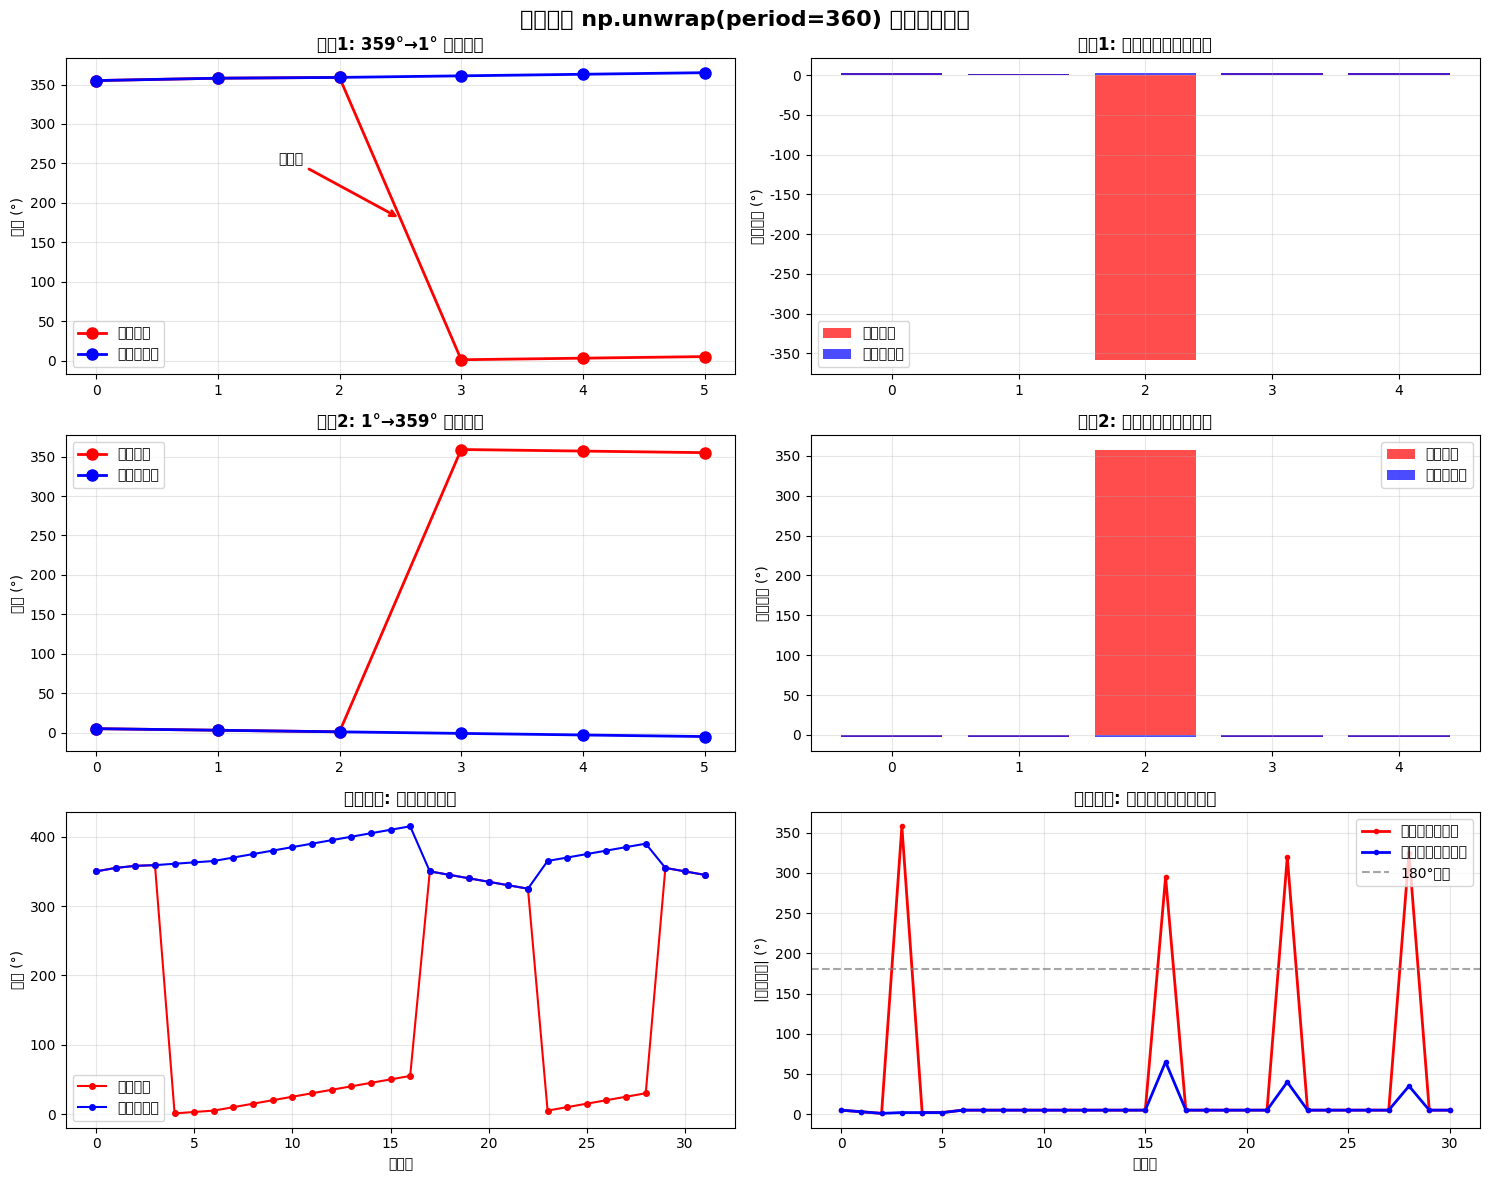


可视化结果总结:
1. 红色线条显示原始角度序列，可见明显的跳变
2. 蓝色线条显示展开后的角度序列，跳变被消除
3. 差值图显示原始数据中存在超过300°的虚假跳变
4. 展开后所有角度差值都在合理范围内（一般<50°）
5. 这样处理后的数据适合用于导数计算和异常检测


In [9]:
# 创建综合可视化图表
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('航迹角度 np.unwrap(period=360) 处理效果对比', fontsize=16, fontweight='bold')

# 情况1: 359°→1° 的处理
time_points_1 = range(len(track_angles_1))
axes[0, 0].plot(time_points_1, track_angles_1, 'ro-', linewidth=2, markersize=8, label='原始角度')
axes[0, 0].plot(time_points_1, unwrapped_1, 'bo-', linewidth=2, markersize=8, label='展开后角度')
axes[0, 0].set_title('情况1: 359°→1° 跳变处理', fontweight='bold')
axes[0, 0].set_ylabel('角度 (°)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
# 标注关键点
axes[0, 0].annotate('跳变点', xy=(2.5, 180), xytext=(1.5, 250),
                   arrowprops=dict(arrowstyle='->', color='red', lw=2))

# 情况1的角度差值
diffs_orig_1 = np.diff(track_angles_1)
diffs_unwrapped_1 = np.diff(unwrapped_1)
axes[0, 1].bar(range(len(diffs_orig_1)), diffs_orig_1, alpha=0.7, label='原始差值', color='red')
axes[0, 1].bar(range(len(diffs_unwrapped_1)), diffs_unwrapped_1, alpha=0.7, label='展开后差值', color='blue')
axes[0, 1].set_title('情况1: 相邻点角度差值对比', fontweight='bold')
axes[0, 1].set_ylabel('角度差值 (°)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 情况2: 1°→359° 的处理  
time_points_2 = range(len(track_angles_2))
axes[1, 0].plot(time_points_2, track_angles_2, 'ro-', linewidth=2, markersize=8, label='原始角度')
axes[1, 0].plot(time_points_2, unwrapped_2, 'bo-', linewidth=2, markersize=8, label='展开后角度')
axes[1, 0].set_title('情况2: 1°→359° 跳变处理', fontweight='bold')
axes[1, 0].set_ylabel('角度 (°)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 情况2的角度差值
diffs_orig_2 = np.diff(track_angles_2)
diffs_unwrapped_2 = np.diff(unwrapped_2)
axes[1, 1].bar(range(len(diffs_orig_2)), diffs_orig_2, alpha=0.7, label='原始差值', color='red')
axes[1, 1].bar(range(len(diffs_unwrapped_2)), diffs_unwrapped_2, alpha=0.7, label='展开后差值', color='blue')
axes[1, 1].set_title('情况2: 相邻点角度差值对比', fontweight='bold')
axes[1, 1].set_ylabel('角度差值 (°)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 复杂序列的处理
time_points_complex = range(len(track_angles_complex))
axes[2, 0].plot(time_points_complex, track_angles_complex, 'ro-', linewidth=1.5, markersize=4, label='原始角度')
axes[2, 0].plot(time_points_complex, unwrapped_complex, 'bo-', linewidth=1.5, markersize=4, label='展开后角度')
axes[2, 0].set_title('复杂序列: 多次跳变处理', fontweight='bold')
axes[2, 0].set_xlabel('时间点')
axes[2, 0].set_ylabel('角度 (°)')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 复杂序列的差值对比（绝对值）
diffs_orig_complex = np.abs(np.diff(track_angles_complex))
diffs_unwrapped_complex = np.abs(np.diff(unwrapped_complex))
axes[2, 1].plot(range(len(diffs_orig_complex)), diffs_orig_complex, 'r.-', label='原始差值绝对值', linewidth=2)
axes[2, 1].plot(range(len(diffs_unwrapped_complex)), diffs_unwrapped_complex, 'b.-', label='展开后差值绝对值', linewidth=2)
axes[2, 1].axhline(y=180, color='gray', linestyle='--', alpha=0.7, label='180°阈值')
axes[2, 1].set_title('复杂序列: 角度差值绝对值对比', fontweight='bold')
axes[2, 1].set_xlabel('时间点')
axes[2, 1].set_ylabel('|角度差值| (°)')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印总结
print("\n" + "="*70)
print("可视化结果总结:")
print("1. 红色线条显示原始角度序列，可见明显的跳变")
print("2. 蓝色线条显示展开后的角度序列，跳变被消除")
print("3. 差值图显示原始数据中存在超过300°的虚假跳变")
print("4. 展开后所有角度差值都在合理范围内（一般<50°）")
print("5. 这样处理后的数据适合用于导数计算和异常检测")

## 总结与应用

### `np.unwrap(period=360)` 工作原理总结：

1. **问题识别**：检测相邻角度差值是否超过 180°
2. **跳变校正**：
   - 当 `diff > 180°` 时（如 1°→359°），在当前点减去 360°
   - 当 `diff < -180°` 时（如 359°→1°），在当前点加上 360°
3. **累积效应**：校正会影响后续所有点，保持连续性

### 在 `filterclassic.py` 中的应用：

```python
if column == "track":
    # 航迹角需要先解包，避免在 0/360° 处产生虚假跳变
    val = np.unwrap(val, period=360)
```

这一步预处理确保了后续的导数计算能够正确反映飞机的真实转向幅度，而不会被 0/360 度边界的数值跳变所干扰。

### 关键优势：

- **保持物理意义**：展开后的角度序列反映真实的累积转向
- **便于导数计算**：消除虚假跳变，使得角速度计算更准确  
- **改善异常检测**：避免将正常的边界跨越误判为异常突刺